In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from context_flux_no.simulations.pde import Burgers1D
from context_flux_no.waveforms.fourier import TruncatedFourier1D
from context_flux_no.waveforms.grf import (
    GaussianCov,
    GaussianRandomField1D,
)
from tqdm import tqdm


jax.config.update("jax_enable_x64", True)

INFO:2025-10-07 22:47:08,388:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2025-10-07 22:47:08,388 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


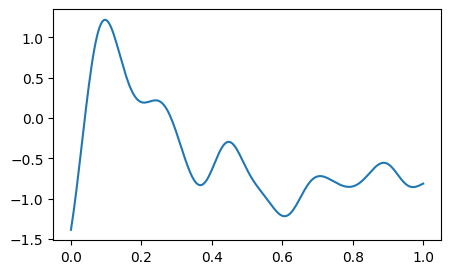

In [2]:
x = jnp.linspace(0, 1, 256)
u0 = GaussianRandomField1D(GaussianCov(0.1)).sample(x, jax.random.key(1))

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0)

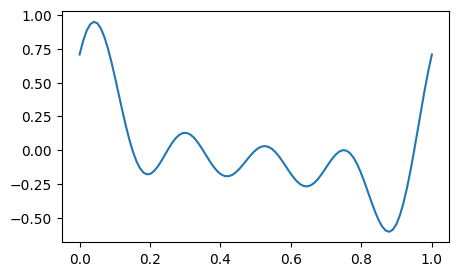

In [3]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [4]:
grf = GaussianRandomField1D(GaussianCov(0.1))
u0_func = lambda x_: grf.sample(x_, key=jax.random.key(0))
burgers = Burgers1D()
# u0_func = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)

sol = burgers.solve_pyclaw(u0_func, (0.0, 1.0), 256, (0.0, 0.2), 500, "periodic")

2025-10-07 22:47:13,958 INFO CLAW: Solution 0 computed for time t=0.000000
2025-10-07 22:47:13,959 INFO CLAW: Solution 1 computed for time t=0.000400
2025-10-07 22:47:13,960 INFO CLAW: Solution 2 computed for time t=0.000800
2025-10-07 22:47:13,960 INFO CLAW: Solution 3 computed for time t=0.001200
2025-10-07 22:47:13,962 INFO CLAW: Solution 4 computed for time t=0.001600
2025-10-07 22:47:13,962 INFO CLAW: Solution 5 computed for time t=0.002000
2025-10-07 22:47:13,963 INFO CLAW: Solution 6 computed for time t=0.002400
2025-10-07 22:47:13,965 INFO CLAW: Solution 7 computed for time t=0.002800
2025-10-07 22:47:13,965 INFO CLAW: Solution 8 computed for time t=0.003200
2025-10-07 22:47:13,966 INFO CLAW: Solution 9 computed for time t=0.003600
2025-10-07 22:47:13,967 INFO CLAW: Solution 10 computed for time t=0.004000
2025-10-07 22:47:13,968 INFO CLAW: Solution 11 computed for time t=0.004400
2025-10-07 22:47:13,969 INFO CLAW: Solution 12 computed for time t=0.004800
2025-10-07 22:47:13,97

2025-10-07 22:47:14,031 INFO CLAW: Solution 80 computed for time t=0.032000
2025-10-07 22:47:14,032 INFO CLAW: Solution 81 computed for time t=0.032400
2025-10-07 22:47:14,033 INFO CLAW: Solution 82 computed for time t=0.032800
2025-10-07 22:47:14,034 INFO CLAW: Solution 83 computed for time t=0.033200
2025-10-07 22:47:14,035 INFO CLAW: Solution 84 computed for time t=0.033600
2025-10-07 22:47:14,036 INFO CLAW: Solution 85 computed for time t=0.034000
2025-10-07 22:47:14,037 INFO CLAW: Solution 86 computed for time t=0.034400
2025-10-07 22:47:14,038 INFO CLAW: Solution 87 computed for time t=0.034800
2025-10-07 22:47:14,039 INFO CLAW: Solution 88 computed for time t=0.035200
2025-10-07 22:47:14,040 INFO CLAW: Solution 89 computed for time t=0.035600
2025-10-07 22:47:14,041 INFO CLAW: Solution 90 computed for time t=0.036000
2025-10-07 22:47:14,041 INFO CLAW: Solution 91 computed for time t=0.036400
2025-10-07 22:47:14,042 INFO CLAW: Solution 92 computed for time t=0.036800
2025-10-07 2

In [5]:
sol

<xarray.Dataset> Size: 1MB
Dimensions:  (sample: 1, t: 501, dim: 1, x: 256, param: 1)
Coordinates:
  * t        (t) float64 4kB 0.0 0.0004 0.0008 0.0012 ... 0.1992 0.1996 0.2
  * x        (x) float64 2kB 0.001953 0.005859 0.009766 ... 0.9902 0.9941 0.998
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U2 8B 'nu'
Dimensions without coordinates: sample
Data variables:
    values   (sample, t, dim, x) float64 1MB 0.9167 0.9816 ... 0.1738 0.1897
    coeffs   (sample, param) float64 8B 0.0

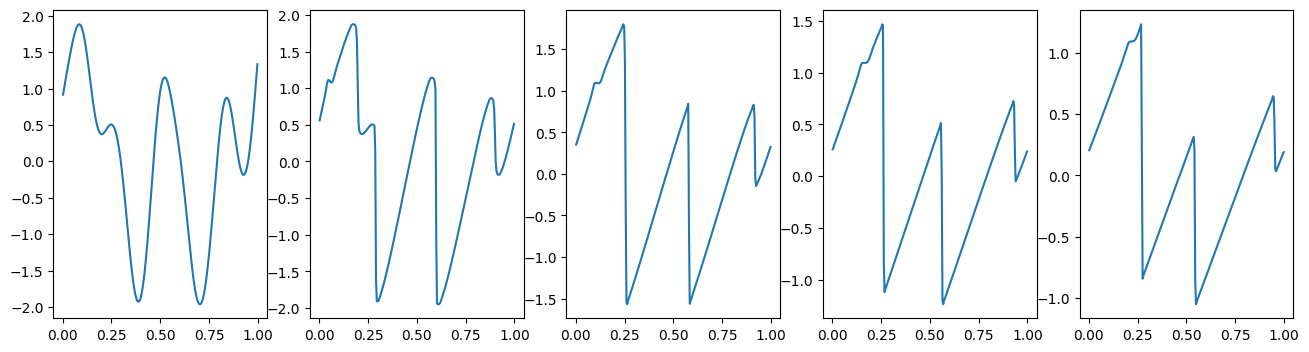

In [6]:
t_vals = (0, 124, 249, 374, 499)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
u = sol["values"]
for j, t_i in enumerate(t_vals):
    axes[j].plot(u["x"], u.isel(sample=0, t=t_i, dim=0))

In [7]:
NUM_SAMPLES = 50
SEED = 0


burgers = Burgers1D()
grf = GaussianRandomField1D(GaussianCov(0.1))

keys = jax.random.split(jax.random.key(SEED), NUM_SAMPLES)
solutions = []
for key in tqdm(keys):
    u0_func = lambda x_: grf.sample(x_, key=key)
    sol = burgers.solve_pyclaw(
        u0_func, (0.0, 1.0), 256, (0.0, 0.2), 500, "periodic", verbose=False
    )
    solutions.append(sol)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:07<00:00,  6.44it/s]


In [8]:
dataset = xr.concat(solutions, "sample")

In [9]:
dataset

<xarray.Dataset> Size: 51MB
Dimensions:  (sample: 50, t: 501, dim: 1, x: 256, param: 1)
Coordinates:
  * t        (t) float64 4kB 0.0 0.0004 0.0008 0.0012 ... 0.1992 0.1996 0.2
  * x        (x) float64 2kB 0.001953 0.005859 0.009766 ... 0.9902 0.9941 0.998
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U2 8B 'nu'
Dimensions without coordinates: sample
Data variables:
    values   (sample, t, dim, x) float64 51MB 0.09868 0.1039 ... 0.4499 0.4647
    coeffs   (sample, param) float64 400B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [10]:
savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "burgers_train.hdf5")